## Step 1: Data Exploration & Cleaning

Importations des Modules

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Voir les informations générales du fichier, les types des colonnes, les valeurs manquantes et les doublons

In [ ]:
df = pd.read_csv("project_dataset.csv", sep=";", decimal=",")
print(df.isnull().sum())
df.duplicated().sum()

Date                                                                                              60
Service                                                                                          240
Gare de départ                                                                                    59
Gare d'arrivée                                                                                    59
Durée moyenne du trajet                                                                          240
Nombre de circulations prévues                                                                   240
Nombre de trains annulés                                                                         239
Commentaire annulations                                                                        11493
Nombre de trains en retard au départ                                                             240
Retard moyen des trains en retard au départ                                                

np.int64(174)

Supprime les colonnes ou le mot Commentaire apparait

In [ ]:
for col in df.columns:
    if "Commentaire" in col:
        df = df.drop(columns=col)

Ce code supprime les lignes incomplètes (ou il manque une gare ou le nombre de trains prévu).

In [ ]:
df = df.dropna(subset=["Gare de départ", "Gare d'arrivée", "Nombre de circulations prévues"])

Ce code convertit la colonne de texte avec des virgules en les remplaçant par des points.

In [ ]:
df["Nombre de circulations prévues"] = df["Nombre de circulations prévues"].str.replace(",", ".")
df["Nombre de circulations prévues"] = pd.to_numeric(df["Nombre de circulations prévues"])

df["Retard moyen de tous les trains au départ"] = df["Retard moyen de tous les trains au départ"].str.replace(",", ".")
df["Retard moyen de tous les trains au départ"] = pd.to_numeric(df["Retard moyen de tous les trains au départ"], errors="coerce")

df["Retard moyen de tous les trains à l'arrivée"] = df["Retard moyen de tous les trains à l'arrivée"].str.replace(",", ".")
df["Retard moyen de tous les trains à l'arrivée"] = pd.to_numeric(df["Retard moyen de tous les trains à l'arrivée"], errors="coerce")


Conserve que les vrais trajets (où le nombre de trains prévus est supérieur à zéro).

In [ ]:
df = df[df["Nombre de circulations prévues"] > 0]

Conversion en format Datetime (gère les - et les /)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

Création des deux colonnes d'analyse

In [ ]:
df['Annee'] = df['Date'].dt.year
df['Mois'] = df['Date'].dt.month

Nettoyer les espaces invisibles et les gares qui sont écris 2x différament (majuscules)

In [ ]:
df["Gare de départ"] = df["Gare de départ"].str.upper()
df["Gare d'arrivée"] = df["Gare d'arrivée"].str.upper()

df["Gare de départ"] = df["Gare de départ"].str.strip()
df["Gare d'arrivée"] = df["Gare d'arrivée"].str.strip()

df["Gare de départ"] = df["Gare de départ"].str.replace("ST ", "SAINT ")
df["Gare d'arrivée"] = df["Gare d'arrivée"].str.replace("ST ", "SAINT ")

Création du nouveau fichier csv clean

In [ ]:
df.to_csv("cleaned_dataset.csv", index=False)

## Step 2: Data Visualization & Analysis

Calcul de la différence de retard entre les trains National VS International

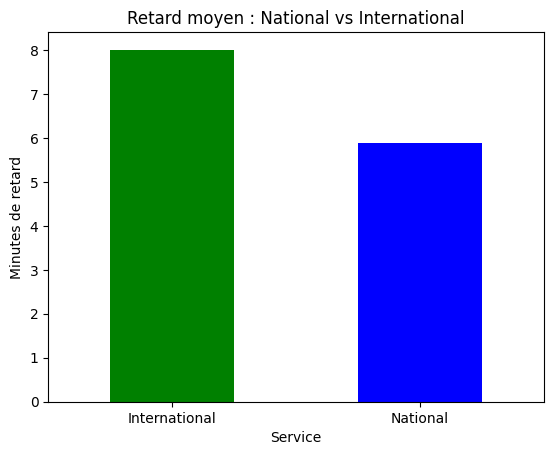

In [ ]:
df = pd.read_csv("cleaned_dataset.csv")
df.groupby("Service")["Retard moyen de tous les trains à l'arrivée"].mean().plot(kind="bar", color=["green", "blue"])
plt.title("Retard moyen : National vs International")
plt.ylabel("Minutes de retard")
plt.xticks(rotation=0)
plt.show()

Retard moyen par mois

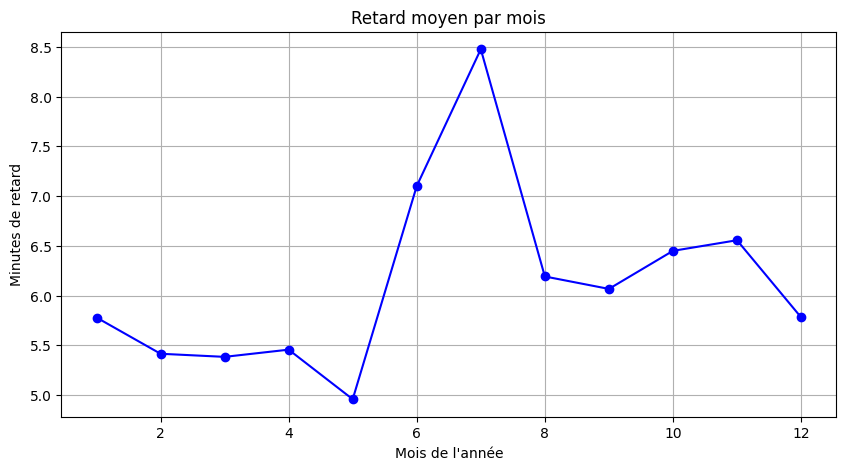

In [ ]:
df["Retard moyen de tous les trains à l'arrivée"] = pd.to_numeric(df["Retard moyen de tous les trains à l'arrivée"], errors='coerce')

retard_par_mois = df.groupby("Mois")["Retard moyen de tous les trains à l'arrivée"].mean()

plt.figure(figsize=(10, 5))
plt.plot(retard_par_mois.index, retard_par_mois.values, marker='o', color='blue')

plt.title("Retard moyen par mois")
plt.xlabel("Mois de l'année")
plt.ylabel("Minutes de retard")
plt.grid(True)
plt.show()

Nombre moyen de trains par mois (Top 10 gares)

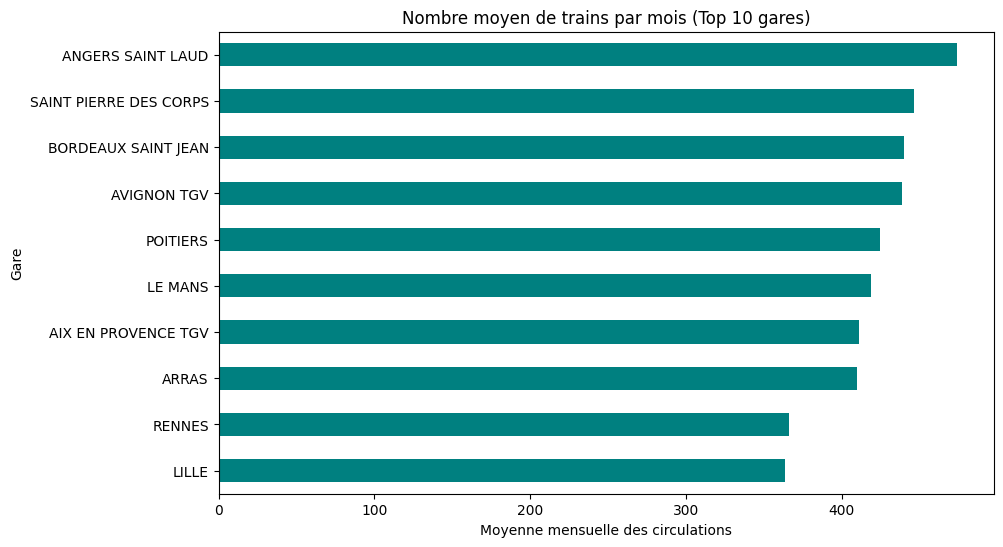

In [ ]:
#vérifie que le nombre de circulations est un chiffre
df["Nombre de circulations prévues"] = pd.to_numeric(df["Nombre de circulations prévues"], errors='coerce')

#calcule moyenne par mois pour chaque gare
trafic_mensuel_moyen = df.groupby("Gare de départ")["Nombre de circulations prévues"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
trafic_mensuel_moyen.plot(kind='barh', color='teal')

plt.title("Nombre moyen de trains par mois (Top 10 gares)")
plt.xlabel("Moyenne mensuelle des circulations")
plt.ylabel("Gare")
plt.gca().invert_yaxis()
plt.show()